# Chapter 4. 양자 신경망의 기초

## 개요
이 노트북에서는 Qiskit Machine Learning에서 제공하는 양자 신경망(Quantum Neural Network, QNN) 구현체를 소개한다.

Qiskit Machine Learning은 두 가지 양자 신경망(QNN) 구현체를 제공한다:

1. **`EstimatorQNN`**: 추정기(Estimator) 기반 양자 신경망으로, 양자 회로의 기댓값(Expectation Value)을 출력으로 반환한다.
2. **`SamplerQNN`**: 샘플러(Sampler) 기반 양자 신경망으로, 양자 회로의 측정 확률(Measurement Probability)을 출력으로 반환한다.

이 튜토리얼에서는 다음 내용을 다룬다:

1. [QNN 인스턴스 생성 방법](#2.-QNN-인스턴스-생성-방법)
2. [순전파(Forward Pass) 실행 방법](#3.-순전파-실행-방법)
3. [역전파(Backward Pass) 실행 방법](#4.-역전파-실행-방법)
4. [고급 기능](#5.-고급-기능)


## 1. 소개

### 1.1. 양자 신경망(Quantum Neural Network) vs. 고전 신경망(Classical Neural Network)

고전 신경망(Classical Neural Network)은 데이터의 패턴을 학습하기 위해 설계된 알고리즘 모델이다. 이 모델은 생물학적 뉴런(Neuron)에서 영감을 받았으며, 행렬-벡터 곱(Matrix-Vector Multiplication)과 비선형 활성화 함수(Nonlinear Activation Function)를 결합하여 입력-출력 매핑(Input-Output Mapping)을 수행한다.

양자 신경망(QNN)은 매개변수화 양자 회로(Parameterized Quantum Circuit, PQC)를 기반으로 하며, 두 가지 관점에서 이해할 수 있다:

- **양자 컴퓨팅 관점**: 변분 양자 알고리즘(Variational Quantum Algorithm, VQA)의 핵심 구성 요소로서, 매개변수화 양자 회로의 출력(기댓값 또는 측정 확률)을 제공한다.
- **머신러닝 관점**: 고전 신경망의 양자 버전으로서, 학습 가능한 가중치(Trainable Weight)를 가진 모델이다.


위의 두 관점은 상호 보완적이며, 반드시 엄격한 정의에 의존하지 않는다는 점을 유의해야 한다. 실제로 양자 신경망은 고전 레이어(Classical Layer)와 결합하여 **하이브리드 양자-고전 신경망(Hybrid Quantum-Classical Neural Network)**을 구성할 수도 있다.

두 QNN 구현체의 주요 차이점은 다음과 같다:

- `EstimatorQNN`: 관측량(Observable)의 기댓값(Expectation Value)을 계산하여 연속적인 실수값을 출력한다.
- `SamplerQNN`: 양자 회로의 측정 결과를 준확률 분포(Quasi-probability Distribution)로 반환하며, `interpret` 함수를 통해 커스텀 후처리(Post-processing)가 가능하다.


***

이제 두 가지 `NeuralNetwork` 구현체의 구체적인 예제를 살펴보겠다. 먼저, 재현성(Reproducibility)을 위해 알고리즘 시드(Algorithm Seed)를 설정한다.


In [ ]:
# 필요한 패키지(Package) 설치
%pip install

In [1]:
# 재현성(Reproducibility)을 위한 랜덤 시드(Random Seed) 설정
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 42

## 2. QNN 인스턴스 생성 방법

### 2.1. `EstimatorQNN`

`EstimatorQNN`은 매개변수화 양자 회로(Parameterized Quantum Circuit)를 입력으로 받아, 하나 이상의 관측량(Observable)에 대한 기댓값(Expectation Value)을 계산한다. 관측량(Observable)을 명시적으로 설정하지 않으면, 기본적으로 `Z^n` (n은 큐비트(Qubit) 수) 관측량이 사용된다.

먼저, 1개의 큐비트(Qubit)를 사용하는 간단한 매개변수화 양자 회로(PQC)를 생성하겠다. 이 회로는 1개의 입력 매개변수(Input Parameter)와 1개의 가중치 매개변수(Weight Parameter)를 가진다.


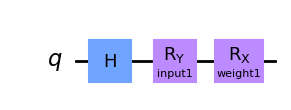

In [2]:
# 1큐비트(Qubit) 매개변수화 양자 회로(Parameterized Quantum Circuit) 생성
# params1[0]은 입력 매개변수(Input Parameter), params1[1]은 가중치 매개변수(Weight Parameter)
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
qc1.draw("mpl", style="clifford")

이제 기댓값(Expectation Value) 계산을 위한 관측량(Observable)을 생성한다. 관측량을 설정하지 않으면 `EstimatorQNN`이 자동으로 기본 관측량을 생성하지만, 여기서는 명시적으로 Y 관측량(Y Observable)을 정의한다.


In [3]:
# Y 관측량(Observable) 생성 — 큐비트(Qubit) 수에 맞는 파울리 Y 연산자(Pauli-Y Operator)
from qiskit.quantum_info import SparsePauliOp

observable1 = SparsePauliOp.from_list([("Y" * qc1.num_qubits, 1)])

위에서 정의한 양자 회로(Quantum Circuit)와 관측량(Observable)을 사용하여 `EstimatorQNN` 생성자(Constructor)에 전달한다. 또한, 어떤 매개변수(Parameter)가 입력(Input)이고 어떤 것이 가중치(Weight)인지 명시해야 한다.

이 예제에서는 `qiskit.primitives`의 `StatevectorEstimator`를 사용하여 로컬 상태벡터 시뮬레이션(Statevector Simulation)을 수행한다.


In [4]:
# 상태 벡터 추정기(StatevectorEstimator)를 사용하여 EstimatorQNN 생성
# circuit: 양자 회로(Quantum Circuit), observables: 관측량(Observable)
# input_params: 입력(Input) 매개변수, weight_params: 가중치(Weight) 매개변수
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator as Estimator

estimator = Estimator()
estimator_qnn = EstimatorQNN(
    circuit=qc1,
    observables=observable1,
    input_params=[params1[0]],
    weight_params=[params1[1]],
    estimator=estimator,
)
estimator_qnn

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


다음 섹션에서 QNN을 사용하는 방법을 살펴볼 것이다. 그 전에, `SamplerQNN` 클래스(Class)도 알아보겠다.


### 2.2. `SamplerQNN`

`SamplerQNN`은 `EstimatorQNN`과 유사하게 인스턴스화되지만, 양자 회로의 측정 결과 확률(Measurement Probability)을 직접 반환한다는 차이가 있다. 내부적으로는 `Sampler` 프리미티브(Primitive)를 사용하며, 비트스트링(Bitstring)의 준확률 분포(Quasi-probability Distribution)를 출력한다.


`SamplerQNN`을 위해 다른 양자 회로를 생성하겠다. 이 경우, 2개의 입력 매개변수(Input Parameter)와 4개의 가중치 매개변수(Weight Parameter)를 사용한다.


input parameters: ['input[0]', 'input[1]']
weight parameters: ['weight[0]', 'weight[1]', 'weight[2]', 'weight[3]']


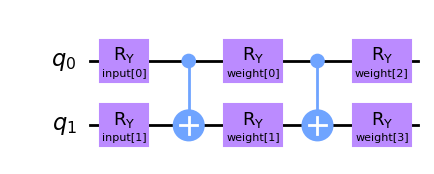

In [5]:
# SamplerQNN용 2큐비트(Qubit) 양자 회로(Quantum Circuit) 생성
# 2개의 입력 매개변수(Input Parameter)와 4개의 가중치 매개변수(Weight Parameter)
from qiskit.circuit import ParameterVector

inputs2 = ParameterVector("input", 2)
weights2 = ParameterVector("weight", 4)
print(f"input parameters: {[str(item) for item in inputs2.params]}")
print(f"weight parameters: {[str(item) for item in weights2.params]}")

qc2 = QuantumCircuit(2)
qc2.ry(inputs2[0], 0)
qc2.ry(inputs2[1], 1)
qc2.cx(0, 1)
qc2.ry(weights2[0], 0)
qc2.ry(weights2[1], 1)
qc2.cx(0, 1)
qc2.ry(weights2[2], 0)
qc2.ry(weights2[3], 1)

qc2.draw("mpl", style="clifford")

`EstimatorQNN`과 마찬가지로, `SamplerQNN`을 인스턴스화할 때 입력(Input)과 가중치(Weight) 매개변수를 지정해야 한다. 이 경우, 이전과 동일하게 `qiskit.primitives`의 `StatevectorSampler`를 설정한다.


In [6]:
# 상태 벡터 샘플러(StatevectorSampler)를 사용하여 SamplerQNN 생성
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
sampler_qnn = SamplerQNN(circuit=qc2, input_params=inputs2, weight_params=weights2, sampler=sampler)
sampler_qnn

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


위에서 보여준 기본 인자(Argument) 외에도, `SamplerQNN`은 세 가지 추가 설정을 받을 수 있다: `input_gradients`, `interpret`, `output_shape`. 이들에 대해서는 이 튜토리얼의 후반부에서 자세히 다룬다.


## 3. 순전파(Forward Pass) 실행 방법


### 3.1. 설정
실제 환경에서 입력(Input)은 데이터셋(Dataset)에 의해 정의되고, 가중치(Weight)는 학습 알고리즘(Training Algorithm)에 의해 결정된다. 이 노트북에서는 설명을 위해 무작위(Random) 입력과 가중치를 사용한다.


#### 3.1.1. `EstimatorQNN` 예제


In [7]:
# EstimatorQNN용 무작위 입력(Input)과 가중치(Weight) 생성
estimator_qnn_input = algorithm_globals.random.random(estimator_qnn.num_inputs)
estimator_qnn_weights = algorithm_globals.random.random(estimator_qnn.num_weights)

In [8]:
# 입력(Input) 수와 가중치(Weight) 수 확인
print(
    f"Number of input features for EstimatorQNN: {estimator_qnn.num_inputs} \nInput: {estimator_qnn_input}"
)
print(
    f"Number of trainable weights for EstimatorQNN: {estimator_qnn.num_weights} \nWeights: {estimator_qnn_weights}"
)

Number of input features for EstimatorQNN: 1 
Input: [0.77395605]
Number of trainable weights for EstimatorQNN: 1 
Weights: [0.43887844]


#### 3.1.2. `SamplerQNN` 예제


In [9]:
# SamplerQNN용 무작위 입력(Input)과 가중치(Weight) 생성
sampler_qnn_input = algorithm_globals.random.random(sampler_qnn.num_inputs)
sampler_qnn_weights = algorithm_globals.random.random(sampler_qnn.num_weights)

In [10]:
# SamplerQNN의 입력(Input) 수와 가중치(Weight) 수 확인
print(
    f"Number of input features for SamplerQNN: {sampler_qnn.num_inputs} \nInput: {sampler_qnn_input}"
)
print(
    f"Number of trainable weights for SamplerQNN: {sampler_qnn.num_weights} \nWeights: {sampler_qnn_weights}"
)

Number of input features for SamplerQNN: 2 
Input: [0.85859792 0.69736803]
Number of trainable weights for SamplerQNN: 4 
Weights: [0.09417735 0.97562235 0.7611397  0.78606431]


입력(Input)과 가중치(Weight)가 준비되면, 배치 처리 있는(Batched) 경우와 배치 처리 없는(Non-batched) 경우의 순전파(Forward Pass) 결과를 살펴보겠다.


### 3.2. 배치 처리 없는 순전파(Non-batched Forward Pass)


#### 3.2.1. `EstimatorQNN` 예제


`EstimatorQNN`의 순전파(Forward Pass)는 `(batch_size, num_observables)` 형상(Shape)의 배열을 반환한다. 여기서 `batch_size`는 입력 샘플(Sample) 수이고, `num_observables`는 관측량(Observable)의 수이다. 비배치(Non-batched) 입력의 경우 `batch_size = 1`이다.


In [11]:
# EstimatorQNN의 비배치(Non-batched) 순전파(Forward Pass)
# 반환값: (1, num_observables) 형상(Shape)의 기댓값(Expectation Value) 배열
estimator_qnn_forward = estimator_qnn.forward(estimator_qnn_input, estimator_qnn_weights)

print(
    f"Forward pass result for EstimatorQNN: {estimator_qnn_forward}. \nShape: {estimator_qnn_forward.shape}"
)

Forward pass result for EstimatorQNN: [[0.30149308]]. 
Shape: (1, 1)


#### 3.2.2. `SamplerQNN` 예제


커스텀 해석 함수(Custom Interpret Function)가 없는 `SamplerQNN`의 경우, 순전파(Forward Pass)의 예상 출력 형상(Shape)은 `(1, 2**num_qubits)`이다. 비배치(Non-batched) 경우이므로 `batch_size = 1`이다.


In [12]:
# SamplerQNN의 비배치(Non-batched) 순전파(Forward Pass)
# 반환값: (1, 2^num_qubits) 형상(Shape)의 측정 확률(Measurement Probability) 배열
sampler_qnn_forward = sampler_qnn.forward(sampler_qnn_input, sampler_qnn_weights)

print(
    f"Forward pass result for SamplerQNN: {sampler_qnn_forward}.  \nShape: {sampler_qnn_forward.shape}"
)

Forward pass result for SamplerQNN: [[0.01855469 0.26367188 0.54492188 0.17285156]].  
Shape: (1, 4)


### 3.3. 배치 순전파(Batched Forward Pass)


#### 3.3.1. `EstimatorQNN` 예제


`EstimatorQNN`의 순전파(Forward Pass)는 `(batch_size, num_observables)` 형상(Shape)의 배열을 반환한다. 배치 크기(Batch Size)는 입력(Input) 배열의 첫 번째 차원에 의해 결정된다.


In [13]:
# EstimatorQNN의 배치(Batched) 순전파(Forward Pass)
# 동일한 입력(Input)을 2개 전달하여 배치 크기(Batch Size) = 2
estimator_qnn_forward_batched = estimator_qnn.forward(
    [estimator_qnn_input, estimator_qnn_input], estimator_qnn_weights
)

print(
    f"Forward pass result for EstimatorQNN: {estimator_qnn_forward_batched}.  \nShape: {estimator_qnn_forward_batched.shape}"
)

Forward pass result for EstimatorQNN: [[0.29613914]
 [0.27654154]].  
Shape: (2, 1)


#### 3.3.2. `SamplerQNN` 예제


커스텀 해석 함수(Custom Interpret Function)가 없는 `SamplerQNN`의 경우, 배치 순전파(Batched Forward Pass)의 예상 출력 형상(Shape)은 `(batch_size, 2**num_qubits)`이다.


In [14]:
# SamplerQNN의 배치(Batched) 순전파(Forward Pass)
sampler_qnn_forward_batched = sampler_qnn.forward(
    [sampler_qnn_input, sampler_qnn_input], sampler_qnn_weights
)

print(
    f"Forward pass result for SamplerQNN: {sampler_qnn_forward_batched}.  \nShape: {sampler_qnn_forward_batched.shape}"
)

Forward pass result for SamplerQNN: [[0.01660156 0.26757812 0.49707031 0.21875   ]
 [0.02050781 0.26171875 0.49609375 0.22167969]].  
Shape: (2, 4)


## 4. 역전파(Backward Pass) 실행 방법

위에서 정의한 입력(Input)과 가중치(Weight)를 활용하여 역전파(Backward Pass) 실행 방법을 보여주겠다. 역전파는 양자 회로의 기울기(Gradient)를 계산하며, 이는 최적화(Optimization) 과정에서 가중치(Weight)를 업데이트하는 데 사용된다.


### 4.1. 입력 기울기(Input Gradient) 없는 역전파(Backward Pass)


#### 4.1.1. `EstimatorQNN` 예제


`EstimatorQNN`의 경우, 가중치 기울기(Weight Gradient)의 예상 출력 형상(Shape)은 `(batch_size, num_qubits * num_observables, num_weights)`이다. 기본적으로 입력 기울기(Input Gradient)는 `None`으로 반환된다.


In [15]:
# EstimatorQNN의 역전파(Backward Pass) — 가중치 기울기(Weight Gradient) 계산
# 입력 기울기(Input Gradient)는 기본적으로 None 반환
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimator_qnn.backward(
    estimator_qnn_input, estimator_qnn_weights
)

print(
    f"Input gradients for EstimatorQNN: {estimator_qnn_input_grad}.  \nShape: {estimator_qnn_input_grad}"
)
print(
    f"Weight gradients for EstimatorQNN: {estimator_qnn_weight_grad}.  \nShape: {estimator_qnn_weight_grad.shape}"
)

Input gradients for EstimatorQNN: None.  
Shape: None
Weight gradients for EstimatorQNN: [[[0.63272767]]].  
Shape: (1, 1, 1)


#### 4.1.2. `SamplerQNN` 예제


커스텀 해석 함수(Custom Interpret Function)가 없는 `SamplerQNN`의 경우, 가중치 기울기(Weight Gradient)의 예상 출력 형상(Shape)은 `(batch_size, 2**num_qubits, num_weights)`이다.


In [16]:
# SamplerQNN의 역전파(Backward Pass) — 가중치 기울기(Weight Gradient) 계산
sampler_qnn_input_grad, sampler_qnn_weight_grad = sampler_qnn.backward(
    sampler_qnn_input, sampler_qnn_weights
)

print(
    f"Input gradients for SamplerQNN: {sampler_qnn_input_grad}.  \nShape: {sampler_qnn_input_grad}"
)
print(
    f"Weight gradients for SamplerQNN: {sampler_qnn_weight_grad}.  \nShape: {sampler_qnn_weight_grad.shape}"
)

Input gradients for SamplerQNN: None.  
Shape: None
Weight gradients for SamplerQNN: [[[ 0.00634766 -0.10351562 -0.07226562 -0.07226562]
  [ 0.22070312 -0.10449219  0.07519531 -0.23535156]
  [-0.48876953  0.32275391 -0.31933594  0.09033203]
  [ 0.26171875 -0.11474609  0.31640625  0.21728516]]].  
Shape: (1, 4, 4)


### 4.2. 입력 기울기(Input Gradient)를 포함하는 역전파(Backward Pass)

`input_gradients`를 활성화하여 예상 출력 크기가 어떻게 변하는지 살펴보겠다.


In [17]:
# 입력 기울기(Input Gradient) 계산 활성화
estimator_qnn.input_gradients = True
sampler_qnn.input_gradients = True

#### 4.2.1. `EstimatorQNN` 예제


`EstimatorQNN`의 경우, 입력 기울기(Input Gradient)의 예상 출력 형상(Shape)은 `(batch_size, num_qubits * num_observables, num_inputs)`이다.


In [18]:
# EstimatorQNN의 역전파(Backward Pass) — 입력 기울기(Input Gradient) 포함
# 입력 기울기 형상(Shape): (batch_size, num_qubits * num_observables, num_inputs)
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimator_qnn.backward(
    estimator_qnn_input, estimator_qnn_weights
)

print(
    f"Input gradients for EstimatorQNN: {estimator_qnn_input_grad}.  \nShape: {estimator_qnn_input_grad.shape}"
)
print(
    f"Weight gradients for EstimatorQNN: {estimator_qnn_weight_grad}.  \nShape: {estimator_qnn_weight_grad.shape}"
)

Input gradients for EstimatorQNN: [[[0.3038852]]].  
Shape: (1, 1, 1)
Weight gradients for EstimatorQNN: [[[0.63272767]]].  
Shape: (1, 1, 1)


#### 4.2.2. `SamplerQNN` 예제


커스텀 해석 함수(Custom Interpret Function)가 없는 `SamplerQNN`의 경우, 입력 기울기(Input Gradient)의 예상 출력 형상(Shape)은 `(batch_size, 2**num_qubits, num_inputs)`이다.


In [19]:
# SamplerQNN의 역전파(Backward Pass) — 입력 기울기(Input Gradient) 포함
sampler_qnn_input_grad, sampler_qnn_weight_grad = sampler_qnn.backward(
    sampler_qnn_input, sampler_qnn_weights
)

print(
    f"Input gradients for SamplerQNN: {sampler_qnn_input_grad}.  \nShape: {sampler_qnn_input_grad.shape}"
)
print(
    f"Weight gradients for SamplerQNN: {sampler_qnn_weight_grad}.  \nShape: {sampler_qnn_weight_grad.shape}"
)

Input gradients for SamplerQNN: [[[-0.05810547 -0.11425781]
  [ 0.38769531 -0.18896484]
  [-0.34667969  0.07763672]
  [ 0.01708984  0.22558594]]].  
Shape: (1, 4, 2)
Weight gradients for SamplerQNN: [[[ 0.00878906 -0.10546875 -0.06152344 -0.09033203]
  [ 0.21435547 -0.09228516  0.06884766 -0.22900391]
  [-0.48925781  0.33007812 -0.32421875  0.09863281]
  [ 0.26611328 -0.13232422  0.31689453  0.22070312]]].  
Shape: (1, 4, 4)


## 5. 고급 기능(Advanced Functionality)


### 5.1. 여러 관측량(Multiple Observables)을 가진 `EstimatorQNN`


`EstimatorQNN`은 더 복잡한 QNN 아키텍처(Architecture)를 위해 관측량(Observable) 리스트를 전달할 수 있다. 예를 들어(출력 형상(Shape)이 어떻게 변하는지 주목):


In [20]:
# 여러 관측량(Observable)을 가진 EstimatorQNN 생성
# Y 관측량과 Z 관측량 — 출력 형상(Shape)이 (batch_size, 2)로 변경됨
observable2 = SparsePauliOp.from_list([("Z" * qc1.num_qubits, 1)])

estimator_qnn2 = EstimatorQNN(
    circuit=qc1,
    observables=[observable1, observable2],
    input_params=[params1[0]],
    weight_params=[params1[1]],
    estimator=estimator,
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [21]:
# 여러 관측량(Multiple Observables)을 가진 순전파(Forward Pass)와 역전파(Backward Pass)
estimator_qnn_forward2 = estimator_qnn2.forward(estimator_qnn_input, estimator_qnn_weights)
estimator_qnn_input_grad2, estimator_qnn_weight_grad2 = estimator_qnn2.backward(
    estimator_qnn_input, estimator_qnn_weights
)

print(f"Forward output for EstimatorQNN1: {estimator_qnn_forward.shape}")
print(f"Forward output for EstimatorQNN2: {estimator_qnn_forward2.shape}")
print(f"Backward output for EstimatorQNN1: {estimator_qnn_weight_grad.shape}")
print(f"Backward output for EstimatorQNN2: {estimator_qnn_weight_grad2.shape}")

Forward output for EstimatorQNN1: (1, 1)
Forward output for EstimatorQNN2: (1, 2)
Backward output for EstimatorQNN1: (1, 1, 1)
Backward output for EstimatorQNN2: (1, 2, 1)


### 5.2. 커스텀 `interpret` 함수를 가진 `SamplerQNN`


`SamplerQNN`의 일반적인 `interpret` 메서드(Method) 중 하나는 패리티(Parity) 함수이다. 이 함수를 사용하면 이진 분류(Binary Classification)를 수행할 수 있으며, 출력 형상(Output Shape)은 `(batch_size, 2)`가 된다.


In [22]:
# 패리티(Parity) 해석 함수(Interpret Function) — 비트스트링(Bitstring)의 1의 개수에 따라 0 또는 1 반환
# output_shape = 2: 패리티 결과가 0 또는 1이므로 출력 차원(Output Dimension)은 2
parity = lambda x: "{:b}".format(x).count("1") % 2
output_shape = 2  # parity = 0, 1

sampler_qnn2 = SamplerQNN(
    circuit=qc2,
    input_params=inputs2,
    weight_params=weights2,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [23]:
# 커스텀(Custom) 해석 함수(Interpret Function)를 가진 SamplerQNN의 순전파(Forward Pass)와 역전파(Backward Pass)
sampler_qnn_forward2 = sampler_qnn2.forward(sampler_qnn_input, sampler_qnn_weights)
sampler_qnn_input_grad2, sampler_qnn_weight_grad2 = sampler_qnn2.backward(
    sampler_qnn_input, sampler_qnn_weights
)

print(f"Forward output for SamplerQNN1: {sampler_qnn_forward.shape}")
print(f"Forward output for SamplerQNN2: {sampler_qnn_forward2.shape}")
print(f"Backward output for SamplerQNN1: {sampler_qnn_weight_grad.shape}")
print(f"Backward output for SamplerQNN2: {sampler_qnn_weight_grad2.shape}")

Forward output for SamplerQNN1: (1, 4)
Forward output for SamplerQNN2: (1, 2)
Backward output for SamplerQNN1: (1, 4, 4)
Backward output for SamplerQNN2: (1, 2, 4)


## 6. 결론

이 튜토리얼에서는 `qiskit-machine-learning`이 제공하는 두 가지 양자 신경망(QNN) 클래스인 `EstimatorQNN`과 `SamplerQNN`을 소개했다. 인스턴스 생성, 순전파(Forward Pass), 역전파(Backward Pass), 그리고 고급 기능(여러 관측량, 커스텀 해석 함수)에 대해 다루었다.

이후 챕터에서는 이러한 QNN을 기반으로 한 분류기(Classifier)와 회귀기(Regressor)의 구체적인 활용법을 살펴보겠다.


In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright